<a href="https://colab.research.google.com/github/mahathi-kannan/CodeAlpha_CarPricePrediction/blob/main/CodeAlpha_CarPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('car data.csv')

# View the first few rows
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [2]:
# Create a new feature: Age of the car
df['Current_Year'] = 2026
df['Car_Age'] = df['Current_Year'] - df['Year']

# Drop columns that are no longer needed
df = df.drop(['Car_Name', 'Year', 'Current_Year'], axis=1)

# One-hot encode categorical features (Fuel_Type, Selling_type, Transmission)
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features (X) and Target (y)
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

print("Features shape:", X.shape)
print("\nFirst 5 rows of features after encoding:")
print(X.head())

Features shape: (301, 8)

First 5 rows of features after encoding:
   Present_Price  Driven_kms  Owner  Car_Age  Fuel_Type_Diesel  \
0           5.59       27000      0       12             False   
1           9.54       43000      0       13              True   
2           9.85        6900      0        9             False   
3           4.15        5200      0       15             False   
4           6.87       42450      0       12              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
0              True                    False                 True  
1             False                    False                 True  
2              True                    False                 True  
3              True                    False                 True  
4             False                    False                 True  


In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [4]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Model R-squared (Accuracy) Score: {r2 * 100:.2f}%")

Mean Absolute Error (MAE): $0.64
Model R-squared (Accuracy) Score: 95.95%


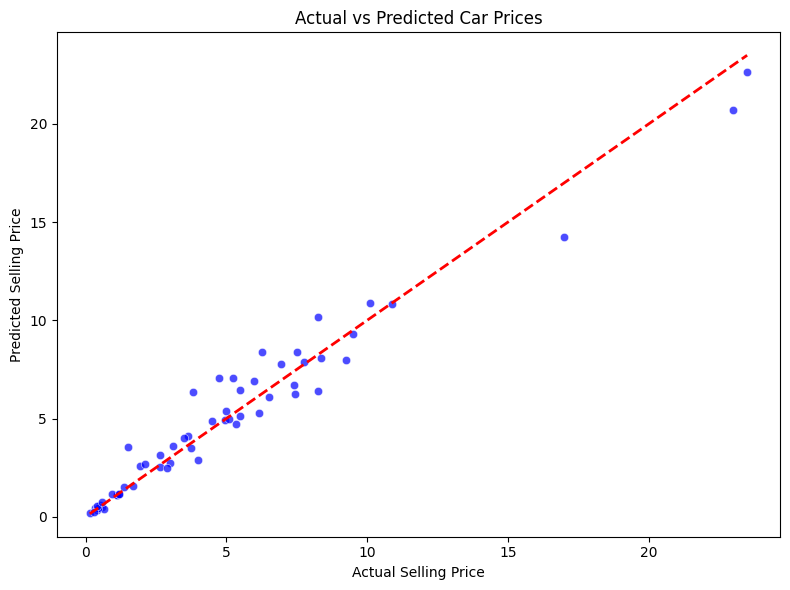

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()